# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_: 
- **Report figure:** Plot of voltage for each node. 
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name): CRUZADO, John Clarence 
- _Student No._: 2024-03034
- _Section_: THU-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report discussion

![Figure 1](Fig1.png)

Figure 1 shows the voltage at the nodes $V_N$ of the resistor ladder, which generally decreases as the node number increases. As we increase the number of nodes in the ladder, the voltage drop lessens.

In solving this problem, we use Kirchhoff's Current Law to solve for the relationship between the potential at each node. Since all resistors have equal resistance, they will get cancelled out in the equation. This leads us to obtaining the following equations:

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$-V_1 - V_2 + 4V_3 - V_4 - V_5 = 0 $$
$$\cdots$$

The abovementioned equations can be assembled into a coefficient matrix whose main diagonal consists of 4 (3 at the first and last diagonal entry), and a series of -1s at the 2 superdiagonals and 2 subdiagonals. When multiplied to a column matrix containing the variables for the nodes $V_i$, we get another column matrix containing the right hand side of the equations, which is essentially a column of 0s, except at the first two entries which has a value of 5.

We then transform this coefficient matrix into a 'banded' matrix, as defined by Mark Newman, and employ the custom linear algebra solver function to obtain the values for the individual potential at the nodes, even at large N.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

### Problem 1: (Newman 6.7) Resistor Ladder

**READ THE INSTRUCTIONS COMPLETELY**

Consider a long chain of resistors wired up like this:

<img src="reschain.png" alt="Alt text" width=95%>

All the resistors have the same resistance $R$.  The power rail at the top is at voltage $V_+=5$V.  The problem is to find the voltages $V_1, \ldots, V_N$ at the internal nodes in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$\cdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\cdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form $A\vec{v} = \vec{w}$ and find the values of the matrix $A$ and the vector $\vec{w}$.

3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the `np.linalg.solve` function.  You need to make use of the fact that the matrix $\vec{A}$ is banded, and uses `banded.py` by Mark Newman which can be obtained from the link: https://public.websites.umich.edu/~mejn/cp/programs.html

5. Plot your voltages in a histogram, make different histograms for varying number of nodes

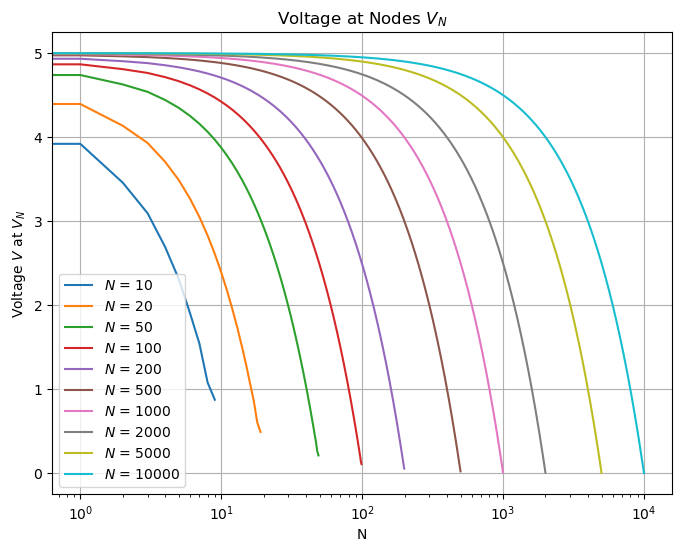

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from banded import banded

up = 2
down = 2

base = np.array([1,2,5])
decades = [base * (10**i) for i in range(1, 4)]
nodes = np.append(np.concatenate(decades), 10000)

plt.figure(figsize=(8,6))

for N in nodes:
    w = np.zeros(N)
    w[0] = 5
    w[1] = 5
    
    C = np.zeros(((up + down + 1),N))
    C[2][:] = 4
    C[2][0] = 3
    C[2][N-1] = 3
    
    C[1][1:] = -1
    C[3][:-1] = -1
    
    C[0][2:] = -1
    C[4][:-2] = -1
    
    v = banded(C,w,2,2)

    plt.plot(v, label=rf"$N$ = {N}")

plt.title("Voltage at Nodes $V_N$")
plt.xlabel("N")
plt.xscale('log')
plt.ylabel("Voltage $V$ at $V_N$")
plt.legend()
plt.grid(True)

plt.show()

#### Problem 1 code summary

Solving the matrix gives us a recursion pattern where the 1st row has entries 3, -1, -1, and 0s (vice versa for the Nth row), the 2nd have -1, 4, -1, -1, and 0s (vice versa for the (N-1)th row), and everything else in between have adjacent entries -1, -1, 4, -1, -1, where the entry '4' is found along the main diagonal (0 elsewhere). The matrix has essentially 1 main diagonal and 4 subdiagonals located above and below the main, which we recast into a banded matrix. Then, using NumPy and banded.py functions, we solve the matrix equation to obtain the voltages $V$ at the nodes $V_N$ for different N, plotted into a log-scale graph.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

### Importing functions from a python file

In [6]:
import samplePackage as sP

In [7]:
sP.createZerosArray(4,5)

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])